# Background
We are developing a data analysis pipeline to characterise the substrate features:
1. colour (HSV mean and standard deviation)

In [ ]:
import os
import sys

sys.path.append('../../..')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:

filepath = r'/Users/kuning/Documents/GitHub/OpenSERS-utils/substrate_BF_characterisation/test dataset/condition 1_replicate 1_result_sBFc_v1.1.npz'
arr:np.ndarray = np.load(filepath, allow_pickle=True)['arr_0']

/var/folders/fm/28xyzlz53pjg6blxlwwr9y940000gn/T/ipykernel_89382/574969862.py:2: RuntimeWarning: invalid value encountered in cast
  plt.imshow(arr.astype(np.uint8))


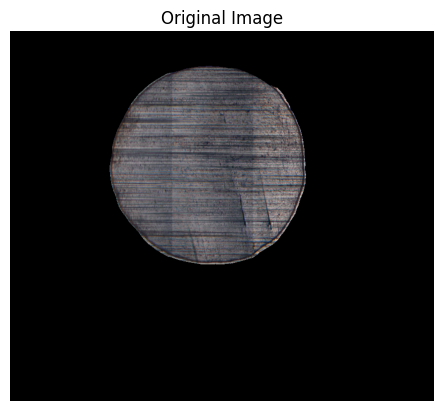

In [3]:
# Show the image stored
plt.imshow(arr.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

# Characterisations

In [4]:
from substrate_BF_characterisation.masking.basic_image_processing import convert_img_RGB2HSV

In [7]:
# Generate the mask for the arr based on the arr values (if it's NaN or not)
mask = ~np.isnan(arr[:,:,0])
arr_uint8 = np.nan_to_num(arr, nan=0).clip(0, 255).astype(np.uint8)
arr_hsv = convert_img_RGB2HSV(arr_uint8)

mean_hue = arr_hsv[:,:,0][mask].mean()
mean_saturation = arr_hsv[:,:,1][mask].mean()
mean_value = arr_hsv[:,:,2][mask].mean()

print(f"Mean Hue: {mean_hue:.2f}")
print(f"Mean Saturation: {mean_saturation:.2f}")
print(f"Mean Value: {mean_value:.2f}")

Mean Hue: 200.51
Mean Saturation: 0.16
Mean Value: 0.41


In [8]:
std_hue = arr_hsv[:,:,0][mask].std()
std_saturation = arr_hsv[:,:,1][mask].std()
std_value = arr_hsv[:,:,2][mask].std()

print(f"Std Hue: {std_hue:.2f}")
print(f"Std Saturation: {std_saturation:.2f}")
print(f"Std Value: {std_value:.2f}")

Std Hue: 104.08
Std Saturation: 0.11
Std Value: 0.09
